In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient Descent Range of Applicability

## Gradient Descent Successes
Gradient descent contains a level of applicability- particularly to convex problems. A single global minimum gurantees an eventual convergence. Those problems which contain no traps and are smooth with differentiable losses are where this algorithm succeeds.

One example of a function which has a successful use of gradient descent is shown below.

In [2]:
def gradientDescent(start=0, learningRate=0.1, iterations=100, tol=1e-6):
    x = start
    path = [x]
    for i in range(iterations):
        step = learningRate * df(x)
        x -= step
        path.append(x)
        if abs(step) < tol:
            break
    return x, path

In [3]:
# x^2 is a convex function.
def f(x):
    return x**2 + 4*x + 4

# The function is smooth and differentiable.
def df(x):
    return 2*x + 4

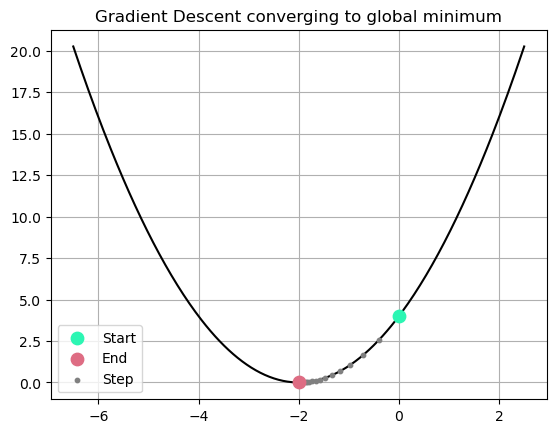

In [4]:
x, path = gradientDescent()

fig, ax = plt.subplots()
xs = np.linspace(-6.5, 2.5, 300)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to global minimum")

plt.show()


## Gradient Descent Failures
There are many examples of specific attributes of a function will result in a weak gradient descent; such as ending at a local minimum rather than the global one. Additional issues with the setup of the gradient descent algorithm, such as learning rate sensitivity, can also result in a breakdown. Too large or too small a learning rate can result in unwanted results.

This portion of the notebook explores the failures of the algorithm shown in Python.

### Functions with Multiple Minima

In the cases where there is a function with multiple minima, there exists the possibility of converging at a local minima which is not global. This can be seen in the function immediately below.

In [5]:
def f(x):
    return x**4 - 4*x**2 + x
def df(x):
    return 4*x**3 - 8*x + 1

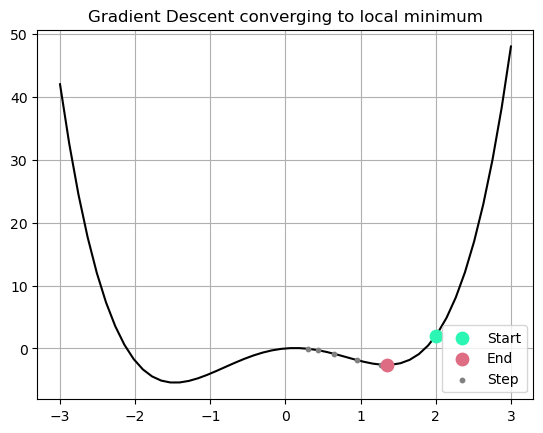

Minimum found at x=1.3470 with f(x)=-2.6186


In [6]:
x, path = gradientDescent(start=2)

fig, ax = plt.subplots()
xs = np.linspace(-3, 3, 50)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to local minimum")

plt.show()
print(f"Minimum found at x={x:.4f} with f(x)={f(x):.4f}")

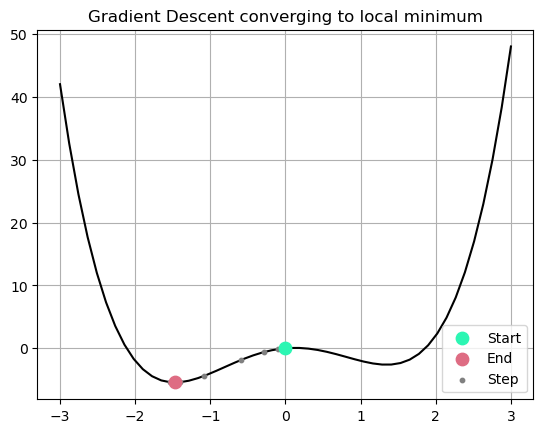

Minimum found at x=-1.4730 with f(x)=-5.4442


In [7]:
x, path = gradientDescent(start=0)

fig, ax = plt.subplots()
xs = np.linspace(-3, 3, 50)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to local minimum")

plt.show()
print(f"Minimum found at x={x:.4f} with f(x)={f(x):.4f}")

In the first graph it is shown that a poor starting point can result in the incorrect minima; while the first correctly identifies it. With the original unmodified gradient descent, there is no way to necessarily know where to start other than a lucky guess.

### Gradient Descent in Higher Dimensions: Saddle Points
In 3-dimensional and higher planes, there can exist saddle points. Saddle points have a local minimum at the same point as a local maximum.

In [8]:
def TwoDimension_gradientDescent(start=(0.0, 0.0), learningRate=0.1, iterations=100, tol=1e-6):
    x = np.array(start, dtype=float)
    path = [x.copy()]
    for _ in range(iterations):
        step = learningRate * df(x[0], x[1])
        x -= step
        path.append(x.copy())
        if np.linalg.norm(step) < tol:
            break
    return x, np.array(path) 

In [9]:
def f(x, y):
    return x**2 - y**2

def df(x, y):
    return np.array([2*x, -2*y])

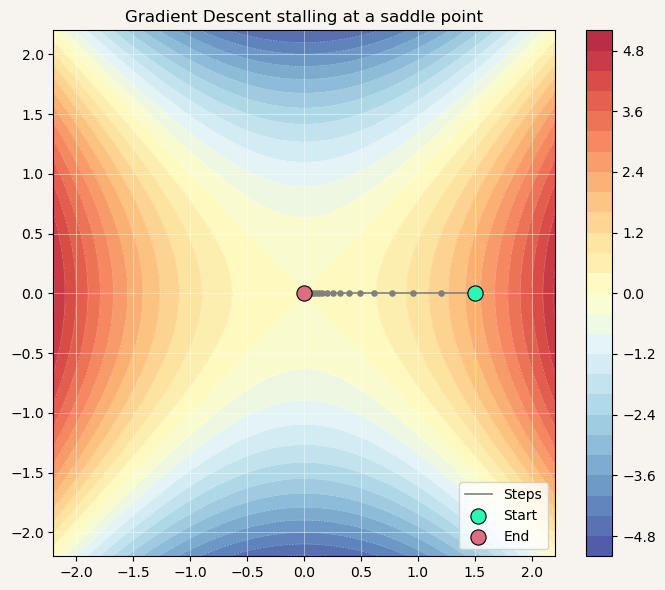

In [10]:
x, path = TwoDimension_gradientDescent(start=(1.5, 0.0))

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#f7f4f0")
ax.set_facecolor("#f7f4f0")

xs = np.linspace(-2.2, 2.2, 400)
ys = np.linspace(-2.2, 2.2, 400)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

cf = ax.contourf(X, Y, Z, levels=30, cmap="RdYlBu_r", alpha=0.85)
ax.contour (X, Y, Z, levels=30, colors="white", linewidths=0.4, alpha=0.5)
fig.colorbar(cf, ax=ax)

ax.plot(path[:, 0], path[:, 1], color="gray", lw=1.2,zorder=4, label="Steps")
ax.scatter(path[:, 0], path[:, 1], c="gray", s=14, zorder=4)
ax.scatter(*path[0],  c="#2CF6B3", s=120, zorder=6, label="Start",edgecolors="black", linewidths=0.8)
ax.scatter(*path[-1], c="#DE6C83", s=120, zorder=6, label="End", edgecolors="black", linewidths=0.8)


ax.legend(loc="lower right")
ax.grid(True, color="white", linewidth=0.5, alpha=0.6)
plt.title("Gradient Descent stalling at a saddle point")

plt.tight_layout()
plt.show()

#### Why does it fail here?
At the ending point, it can be observed dx and dy are equal to zero. Unfortunately, it is not the global minimum. 

It can also be observed gradient descent is not the same as the shortest path to the lowest point. It is only going in the steepest direction.

## Improving the Algorithm
## Pertubation
Pertubation allows us to add random noise to the gradient. By doing this, we can have our algorithm do things that seems counter intuitive to gradient descent, like going up a curve rather than exclusively down.
Additionally, we can detect stalling to see if we are at a flatter point. When we see stalling we can give our algorithm a kick to see if it's current spot is the minimum it wants.

In [11]:
def f(x):
    return x**4 - 4*x**2 + x
def df(x):
    return 4*x**3 - 8*x + 1

In [13]:
def gradientDescentPerturb(start=0, learningRate=0.1, iterations=300, tol=1e-6, noise=1.5, stall_window=8, seed=42):
    rng = np.random.default_rng(seed)
    x = float(start)
    path = [x]
    f_history = [f(x)]
    best_x, best_f = x, f(x)

    for i in range(iterations):
        stalled = (len(f_history) >= stall_window and abs(f_history[-1] - f_history[-stall_window]) < tol * 10)

        if stalled:
            x = x + rng.normal(0, noise)
        else:
            step = learningRate * df(x)
            x   -= step
            if abs(step) < tol:
                break

        x  = float(np.clip(x, -4.0, 4.0))
        fx = f(x)
        path.append(x)
        f_history.append(fx)

        if fx < best_f:
            best_f, best_x = fx, x

    return best_x, path

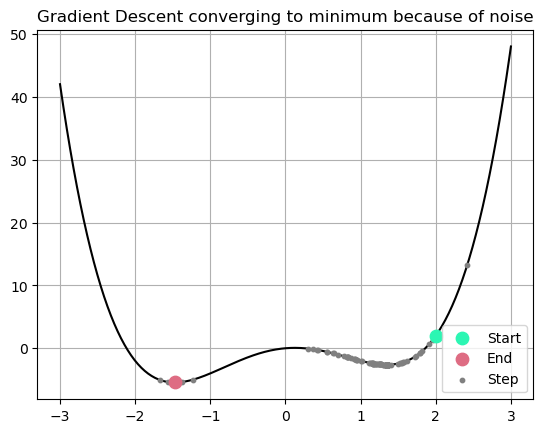

Minimum found at x=-1.4728 with f(x)=-5.4442


In [14]:
x, path = gradientDescentPerturb(start=2, noise=.5)

fig, ax = plt.subplots()
xs = np.linspace(-3, 3, 400)
ax.plot(xs, f(xs), color="black")
ax.scatter(path[0],  f(path[0]),  c='#2CF6B3', s=80, zorder=5, label='Start')
ax.scatter(path[-1], f(path[-1]), c='#DE6C83',  s=80, zorder=5, label='End')
ax.scatter(path, [f(x) for x in path], c='gray', s=10, label='Step', zorder=4)
ax.legend()

ax.grid(True)

plt.title("Gradient Descent converging to minimum because of noise")

plt.show()
print(f"Minimum found at x={x:.4f} with f(x)={f(x):.4f}")

This new algorithm now is able to find the absolute minimum through perturbation and stall detection.